In [1]:
import numpy as np 
import os 
import glob 
import torch 
import random 
from torch import nn
import pickle 
import matplotlib.pyplot as plt 
from matplotlib.colors import LinearSegmentedColormap
from matplotlib import colormaps 
from skimage import measure, feature 
from scipy.spatial import distance 
from collections import defaultdict 
from sklearn.preprocessing import StandardScaler 
from tqdm.auto import tqdm, trange
from scipy.spatial.distance import cdist, pdist, squareform
import tifffile
import seaborn 
import copy

from scipy.ndimage import gaussian_filter  
import sys 
from stedfm import get_pretrained_model_v2 
sys.path.insert(0, "../")
from attribute_datasets import ALSDataset 
from wavelet import detect_spots

OUTPUT_DIR = "./synaptic_development"
os.makedirs(OUTPUT_DIR, exist_ok=True)

/opt/anaconda3/envs/phd-env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def load_svm():
    with open(f"./als-experiment/boundaries/MAE_SMALL_STED_als_svm_PSD95.pkl", "rb") as f:
        return pickle.load(f)

def load_boundary() -> np.ndarray:
    print(f"--- Loading boundary trained from MAE_SMALL_STED embeddings ---")
    data = np.load(f"../als-experiment/boundaries/MAE_SMALL_STED_als_boundary_PSD95.npz")
    boundary, intercept, norm = data["boundary"], data["intercept"], data["norm"]
    return boundary, intercept, norm

boundary, intercept, norm = load_boundary()

--- Loading boundary trained from MAE_SMALL_STED embeddings ---


In [3]:
latent_encoder, model_config = get_pretrained_model_v2(
    name="mae-lightning-small",
    weights="MAE_SMALL_STED",
    as_classifier=True
)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
latent_encoder.to(DEVICE)
latent_encoder.eval()

in_channels 1
--- mae-lightning-small | (https://s3.valeria.science/flclab-foundation-models/models/mae-small-sted.zip) Downloading from URL and extracting zip ---

Loading state_dict from /home-local/Frederic/baselines/mae-small_STED/pl_checkpoint-999.pth
--- Loaded model mae-lightning-small with weights MAE_SMALL_STED ---
--- Added linear probe to all frozen blocks ---


# Generated trajectories

In [4]:
def load_files(path, exclude=None, include=None):
    files = glob.glob(path)
    files.sort()
    files = [f for f in files if os.path.basename(f).split(".")[0].split("_")[-2] != "0"]
    # files = [os.path.basename(f) for f in files]
    trajectory_ids = [os.path.basename(f).split("_")[-4] for f in files]
    timestep_ids = [os.path.basename(f).split("_")[-2] for f in files]
    return np.array(files), np.array(trajectory_ids), np.array(timestep_ids)

path = "/home/frederic/flc-dataset/experiments/diffusion-experiments/als-experiment/PSD95/examples/raw-tif/*.tif"

files, trajectory_ids, timestep_ids = load_files(path)

In [5]:
PIXELSIZE = 0.015

def extract_features(img: np.ndarray, display: bool = False, mode: str = "gen"):
    mask = detect_spots(img, J_list=[3,4], scale_threshold=2.0)
    if display:
        fig, axs = plt.subplots(1, 2, figsize=(10, 5))
        axs[0].imshow(img, cmap="hot", vmin=0, vmax=1)
        axs[1].imshow(mask, cmap="gray")
        for ax in axs:
            ax.axis("off")
        plt.show() 

    mask_label, num_proteins = measure.label(mask, return_num=True)
    
    props = measure.regionprops(mask_label, intensity_image=img)

    # if mode != "real":
    #     filtered_props = []
    #     new_mask = copy.deepcopy(mask) 
    #     for p in props:
    #         if p.mean_intensity >= 0.09:
    #             filtered_props.append(p)
    #         else:
    #             lab = p.label
    #             new_mask[mask_label == lab] = 0 

        
    #     props = filtered_props 
    #     num_proteins = len(props)
    if num_proteins == 0:
        return np.array([])

    coordinates = np.array([p.weighted_centroid for p in props])
    distances = pdist(coordinates) * PIXELSIZE 
    distances = squareform(distances) 
    if len(distances) <= 1:
        nn_distances = [30.0]
    else:
        nn_distances = np.sort(distances, axis=1)[:, 1]
        nn_distances = np.clip(nn_distances, 0, 30.0)

    image_density = num_proteins / (img.shape[0] * img.shape[1] * PIXELSIZE**2)
    density_proteins = (np.sum(distances < 0.5, axis=1) - 1) / 1 # in number of proteins per um^2

    features = []
    counter = 0
    for prop, density, nn in zip(props, density_proteins, nn_distances):
        if density == 0:
            density = 1
        if np.isnan(nn):
            nn = 30.0

        # img = prop.intensity_image
        slc = prop.slice
        slc_img = img[slc]
        label = prop.image

        min_distance = int(0.08 / PIXELSIZE) // 2 + 1 # in pixels
        peaks = feature.peak_local_max(slc_img, min_distance=min_distance, exclude_border=False, labels=label)

        features.append([
            prop.area,
            prop.perimeter,
            prop.mean_intensity,
            prop.eccentricity,
            prop.solidity,
            density,
            len(peaks),
            num_proteins,
        ])

    return np.array(features)
    

def extract_trajectories(files, trajectory_ids, timestep_ids):
    print(f"[---] Processing {len(files)} files [---]")
    unique_trajectories = np.unique(trajectory_ids)

    num_trajectories = len(unique_trajectories) 
    all_trajectory_features = []
    
    for traj_id in unique_trajectories:
        indices = np.where(trajectory_ids == traj_id)
        trajectory_timesteps = timestep_ids[indices]
        trajectory_files = files[indices]
        trajectory_features = []
        for f in trajectory_files:
            img = tifffile.imread(f)
            features = extract_features(img)
            if features.size == 0:
                continue
            img_features = np.mean(features, axis=0)
            trajectory_features.append(img_features)
        
        trajectory_features = np.array(trajectory_features)
        all_trajectory_features.append(trajectory_features)

    all_trajectory_features = np.array(all_trajectory_features)
    return all_trajectory_features

all_trajectory_features = extract_trajectories(files, trajectory_ids, timestep_ids)

[---] Processing 372 files [---]


100%|██████████| 1000/1000 [00:00<00:00, 54596.98it/s]

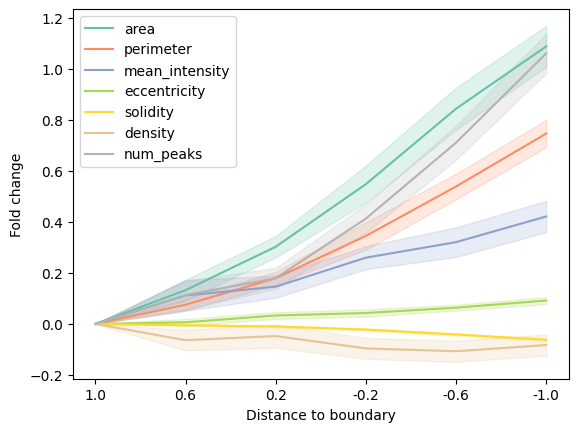

(62, 6, 8)


In [6]:
def get_confidence_interval(bootstrapped_trajectory):
    temp = np.take(bootstrapped_trajectory, indices, axis=axis)
    mean, cid, ciu = np.percentile(np.take(bootstrapped_trajectory, indices, axis=axis), [50, 5.0, 95], axis=0) 
    return mean, cid, ciu   

def bootstrap(trajectories, n=1000):
    out = []
    for _ in trange(n):
        indices = np.random.randint(0, len(trajectories), size=int(len(trajectories)*0.80))
        bootstrap_sample = trajectories[indices]
        mean = np.mean(bootstrap_sample, axis=0)
        out.append(mean)
    out = np.array(out)
    return out

def plot_trajectories(trajectory_features: np.ndarray, n=1000):
    feature_names = ["area", "perimeter", "mean_intensity", "eccentricity", "solidity", "density",  "num_peaks"]# , "num_proteins"]
    cmap = plt.get_cmap("Set2", len(feature_names))
    num_trajectories, num_timesteps, num_features = trajectory_features.shape 
    
    fig = plt.figure()
    ax = fig.add_subplot(111)
    bootstrap_sample = bootstrap(trajectory_features, n=n)
    for feature_idx in range(num_features - 1):
        feature_data = bootstrap_sample[:, :, feature_idx]
        feature_data = (feature_data - feature_data[:, 0:1]) / feature_data[:, 0:1]
        mean, cid, ciu = np.mean(feature_data, axis=0), np.percentile(feature_data, 10.0, axis=0), np.percentile(feature_data, 90.0, axis=0)
        err = np.std(feature_data, axis=0)
        ax.plot(mean, c=cmap(feature_idx), label=feature_names[feature_idx])
        # ax.fill_between(np.arange(num_timesteps), cid, ciu, color=cmap(feature_idx), alpha=0.2)
        ax.fill_between(np.arange(num_timesteps), mean - err, mean + err, color=cmap(feature_idx), alpha=0.2)
        ax.set_xlabel("Distance to boundary")
        ax.set_ylabel("Fold change")
        ax.set_xticks(np.arange(num_timesteps))
        ax.set_xticklabels(["1.0", "0.6", "0.2", "-0.2", "-0.6", "-1.0"])
    ax.legend()
    plt.show()
    fig.savefig(os.path.join(OUTPUT_DIR, f"generated_trajectories.pdf"), dpi=900, transparent=True)

        
            
plot_trajectories(all_trajectory_features, n=1000)
print(all_trajectory_features.shape)


In [7]:
all_generated_features = np.concatenate(all_trajectory_features, axis=0)
generated_minimum = np.quantile(all_generated_features, 0.05, axis=0)
generated_maximum = np.quantile(all_generated_features, 0.95, axis=0)
print(generated_minimum.shape, generated_maximum.shape)



(8,) (8,)


## Random trajectories

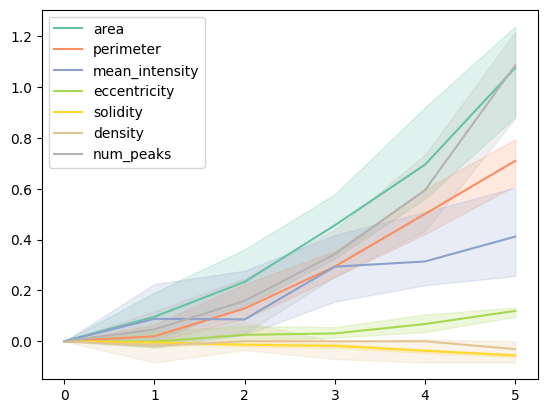

In [8]:
def plot_random_trajectories(trajectory_features: np.ndarray, n=1000):
    fig = plt.figure()
    ax = fig.add_subplot(111)
    feature_names = ["area", "perimeter", "mean_intensity", "eccentricity", "solidity", "density",  "num_peaks"]# , "num_proteins"]
    cmap = plt.get_cmap("Set2", len(feature_names))
    for feature_idx in range(trajectory_features.shape[-1] - 1):
        avg_out = []
        for _ in range(n):
            out = []
            for timestep in range(trajectory_features.shape[1]):
                random_trajectory_id = np.random.randint(0, len(trajectory_features))
                random_trajectory = trajectory_features[random_trajectory_id, timestep, feature_idx] 
                out.append(random_trajectory)
            out = np.array(out)
            avg_out.append(out) 
        avg_out = np.array(avg_out)
        
        avg_out = (avg_out - avg_out[:, 0:1]) / avg_out[:, 0:1]
        mean_out = np.median(avg_out, axis=0)
        # std_out = np.std(avg_out, axis=0)
        cid, ciu = np.percentile(avg_out, 40.0, axis=0), np.percentile(avg_out, 60.0, axis=0)

        ax.plot(mean_out, c=cmap(feature_idx), label=feature_names[feature_idx])
        ax.fill_between(np.arange(trajectory_features.shape[1]), cid, ciu, color=cmap(feature_idx), alpha=0.2)
    ax.legend()
    plt.show()
    fig.savefig(os.path.join(OUTPUT_DIR, f"random_trajectories.pdf"), dpi=900, transparent=True)
            

   

plot_random_trajectories(all_trajectory_features, n=100)

# Real data

In [9]:
dataset_train = ALSDataset(tarpath="/home-local/Frederic/Datasets/ALS/catalogs/PLKO-262-PSD95-train.tar")
dataset_valid = ALSDataset(tarpath="/home-local/Frederic/Datasets/ALS/catalogs/PLKO-262-PSD95-valid.tar")
dataset_test = ALSDataset(tarpath="/home-local/Frederic/Datasets/ALS/catalogs/PLKO-262-PSD95-test.tar")
print(len(dataset_train))

def convert_label(div, dpi):
    if "5" in div and dpi == "7DPI":
        return 0 
    elif "5" in div and dpi == "11DPI":
        return 1 
    elif "14" in div and dpi == "4DPI":
        return 2 
    elif "14" in div and dpi == "7DPI":
        return 3 
    elif "14" in div and dpi == "11DPI":
        return 4 
    else:
        return None

def compute_real_features(dataset):
    labels = []
    all_features = []
    distances = []
    all_embeddings = []
    for i in trange(len(dataset)):
        img, metadata = dataset[i]
        img = img.unsqueeze(0).to(DEVICE)
        with torch.no_grad():
            latent_code = latent_encoder.forward_features(img).squeeze().cpu().numpy()
        img = img.cpu().squeeze().numpy()
        label = convert_label(metadata["label"], metadata["dpi"])
        if label is None:
            continue
        features = extract_features(img, mode="real")
        if features.size == 0:
            print("No valid proteins in image, skipping...")
            continue
        d = (latent_code.dot(boundary.T) + intercept) * norm
        distances.append(d)
        labels.append(label)
        all_embeddings.append(latent_code)
        avg_features = np.mean(features, axis=0)
        all_features.append(avg_features)
    all_features = np.array(all_features) 
    labels = np.array(labels)
    distances = np.array(distances)
    all_embeddings = np.array(all_embeddings)
    return all_features, labels, distances, all_embeddings
        
  

train_real_features, train_real_labels, train_real_distances, train_real_embeddings = compute_real_features(dataset_train)
print(train_real_features.shape, train_real_labels.shape, train_real_embeddings.shape)
valid_real_features, valid_real_labels, valid_real_distances, valid_real_embeddings = compute_real_features(dataset_valid)
print(valid_real_features.shape, valid_real_labels.shape, valid_real_embeddings.shape)
test_real_features, test_real_labels, test_real_distances, test_real_embeddings = compute_real_features(dataset_test)
print(test_real_features.shape, test_real_labels.shape, test_real_embeddings.shape)


1430


  0%|          | 0/1430 [00:00<?, ?it/s]

100%|██████████| 1430/1430 [00:42<00:00, 33.43it/s] 


(1212, 8) (1212,) (1212, 384)


100%|██████████| 517/517 [00:15<00:00, 32.87it/s] 


(460, 8) (460,) (460, 384)


100%|██████████| 486/486 [00:14<00:00, 33.47it/s]

(424, 8) (424,) (424, 384)


In [10]:
valid_minimum = np.quantile(valid_real_features, 0.02, axis=0)
valid_maximum = np.quantile(valid_real_features, 0.98, axis=0)
# valid_minimum = np.min(valid_real_features, axis=0)
# valid_maximum = np.max(valid_real_features, axis=0)

print(valid_minimum.shape, valid_maximum.shape)
normalized_valid_features = (valid_real_features - valid_minimum) / (valid_maximum - valid_minimum)

print(normalized_valid_features.shape)

(8,) (8,)
(460, 8)


## Normalized, sampled real feature trajectories

100%|██████████| 62/62 [00:00<00:00, 22881.38it/s]


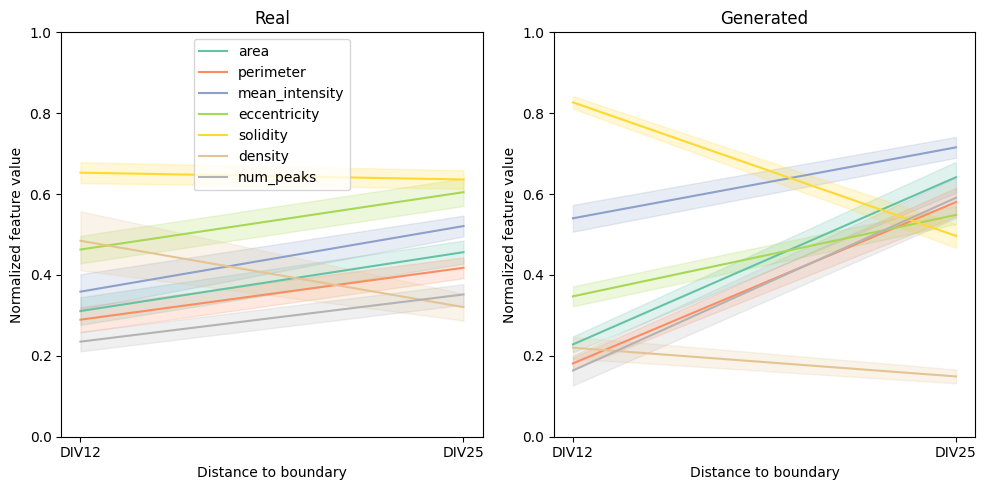

In [11]:
def bootstrap_div12_div25_trajectories(features, labels, n=1000):
    out = []
    for _ in trange(n):
        temp = []
        for label in [np.unique(labels)[0], np.unique(labels)[-1]]:
            indices = np.where(labels == label)[0]
            sample_features = features[indices]
            idx = np.random.randint(0, len(sample_features))
            bootstrap_sample = sample_features[idx]
            temp.append(bootstrap_sample)
        temp = np.array(temp)
        out.append(temp)
    out = np.array(out)
    return out

def plot_normalized_real_trajectories(features: np.ndarray, trajectory_features: np.ndarray, labels: np.ndarray, min_vector: np.ndarray, max_vector: np.ndarray, n: int = 1000):
    bootstrap_trajectories = bootstrap_div12_div25_trajectories(features, labels, n=62)
    feature_names = ["area", "perimeter", "mean_intensity", "eccentricity", "solidity", "density",  "num_peaks"]# , "num_proteins"]
    cmap = plt.get_cmap("Set2", len(feature_names))
    num_trajectories, num_timesteps, num_features = bootstrap_trajectories.shape 
    
    normalized_trajectory_features = (trajectory_features - min_vector) / (max_vector - min_vector)
   
    fig, axs = plt.subplots(1, 2, figsize=(10, 5))
    # ax = fig.add_subplot(111)
    for feature_idx in range(num_features - 1):
        feature_data = bootstrap_trajectories[:, :, feature_idx]
        trajectory_data_before = normalized_trajectory_features[:, [0, 1, 2], feature_idx]
        trajectory_data_after = normalized_trajectory_features[:, [-1, -2, -3], feature_idx]
        trajectory_data_before = np.mean(trajectory_data_before, axis=1)
  
        trajectory_data_after = np.mean(trajectory_data_after, axis=1)


        trajectory_data = np.stack([trajectory_data_before, trajectory_data_after], axis=1)
     
        trajectory_mean = np.mean(trajectory_data, axis=0)
        trajectory_std = np.std(trajectory_data, axis=0)
    
        
        mean = np.mean(feature_data, axis=0)
        std_err = np.std(feature_data, axis=0)
        # sem_err = np.std(feature_data, axis=0) / np.sqrt(len(feature_data))
        cid, ciu = np.percentile(feature_data, 10.0, axis=0), np.percentile(feature_data, 90.0, axis=0)
        real_sem = np.std(feature_data, axis=0) / np.sqrt(len(feature_data))
        gen_sem = np.std(trajectory_data, axis=0) / np.sqrt(len(trajectory_data))
        
        axs[0].plot(mean, c=cmap(feature_idx), label=feature_names[feature_idx])
        axs[1].plot(trajectory_mean, c=cmap(feature_idx))
        axs[0].fill_between(np.arange(num_timesteps), mean - real_sem, mean + real_sem, color=cmap(feature_idx), alpha=0.2)
        axs[1].fill_between(np.arange(2), trajectory_mean - gen_sem, trajectory_mean + gen_sem, color=cmap(feature_idx), alpha=0.2)
        
        for ax in axs:
            ax.set_xlabel("Distance to boundary")
            ax.set_ylabel("Normalized feature value")
            ax.set_xticks(np.arange(2))
            ax.set_xticklabels(["DIV12", "DIV25"])
            ax.set_ylim(0, 1)
    axs[0].set_title("Real")
    axs[1].set_title("Generated")
    axs[0].legend()
    plt.tight_layout()
    plt.show()
    fig.savefig(os.path.join(OUTPUT_DIR, f"real_sampled_trajectories.pdf"), dpi=900, transparent=True, bbox_inches="tight")

plot_normalized_real_trajectories(
    features=normalized_valid_features, 
    trajectory_features=all_trajectory_features,
    labels=valid_real_labels, 
    min_vector=valid_minimum,
    max_vector=valid_maximum,
    n=1)


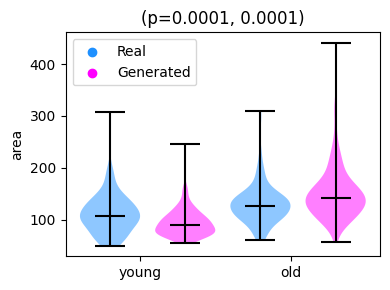

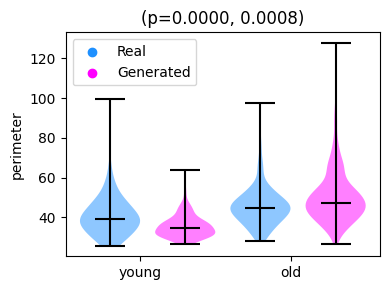

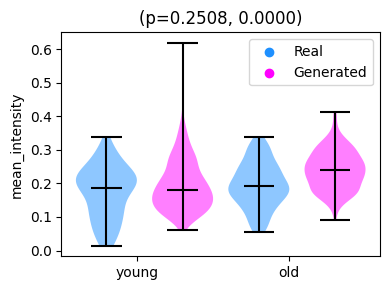

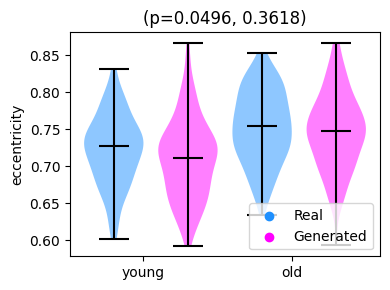

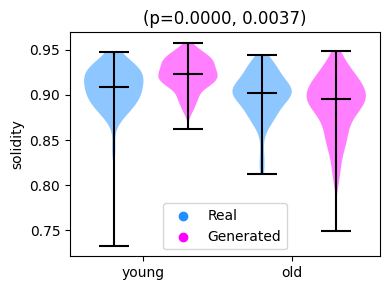

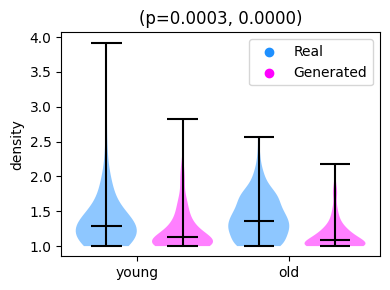

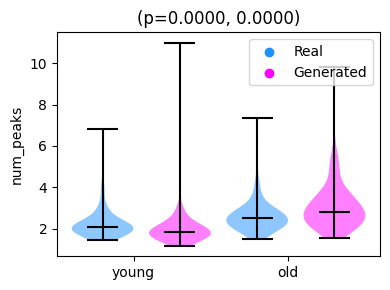

In [12]:
from scipy.stats import mannwhitneyu, ttest_ind, wilcoxon

def feature_violins(real_features: np.ndarray, real_labels: np.ndarray, generated_features: np.ndarray, feature_names: list[str]):
    div12_features = real_features[real_labels == 0]
    div25_features = real_features[real_labels == 4]
    generated_young = generated_features[:, [0, 1, 2], :]
    generated_old = generated_features[:, [3, 4, 5], :]
    
    generated_young = np.concatenate(generated_young, axis=0)
    generated_old = np.concatenate(generated_old, axis=0)

    for feature_idx, feature_name in enumerate(feature_names):
        div12_feat = div12_features[:, feature_idx]
        div25_feat = div25_features[:, feature_idx]
        generated_young_feat = generated_young[:, feature_idx]
        generated_old_feat = generated_old[:, feature_idx]

        young_pval = mannwhitneyu(div12_feat, generated_young_feat).pvalue
        old_pval = mannwhitneyu(div25_feat, generated_old_feat).pvalue

        real_violin_data = [div12_feat, div25_feat]
        generated_violin_data = [generated_young_feat, generated_old_feat]
        x1 = np.arange(len(real_violin_data))
        x2 = [item + 0.5 for item in x1]

        fig = plt.figure(figsize=(4,3))
        ax = fig.add_subplot(111)
        real_violins = ax.violinplot(real_violin_data, positions=x1, showmedians=True, widths=[0.4, 0.4])
        generated_violins = ax.violinplot(generated_violin_data, positions=x2, showmedians=True, widths=[0.4, 0.4])
        
        for body in real_violins['bodies']:
            body.set_facecolor('dodgerblue')
            body.set_alpha(0.5)
        for body in generated_violins['bodies']:
            body.set_facecolor('fuchsia')
            body.set_alpha(0.5)

        for collection in (
            real_violins['cmins'], real_violins['cmaxes'], real_violins['cbars'], real_violins['cmedians'],
            generated_violins['cmins'], generated_violins['cmaxes'], generated_violins['cbars'], generated_violins['cmedians']
        ):
            collection.set_color("black")

        x = np.arange(len(real_violin_data))
        x = [item + 0.2 for item in x]
        ax.set_xticks(x)
        ax.set_xticklabels(["young", "old"])
        ax.set_title(f"(p={young_pval:.4f}, {old_pval:.4f})")
        ax.set_ylabel(feature_name)
        custom_legend = [plt.scatter([], [], c="dodgerblue", label="Real"), plt.scatter([], [], c="fuchsia", label="Generated")]
        ax.legend(handles=custom_legend)
        plt.tight_layout()
        plt.show() 
        plt.close(fig)
            
        
feature_violins(
    real_features=valid_real_features,
    real_labels=valid_real_labels,
    generated_features=all_trajectory_features,
    feature_names=["area", "perimeter", "mean_intensity", "eccentricity", "solidity", "density",  "num_peaks"]
)

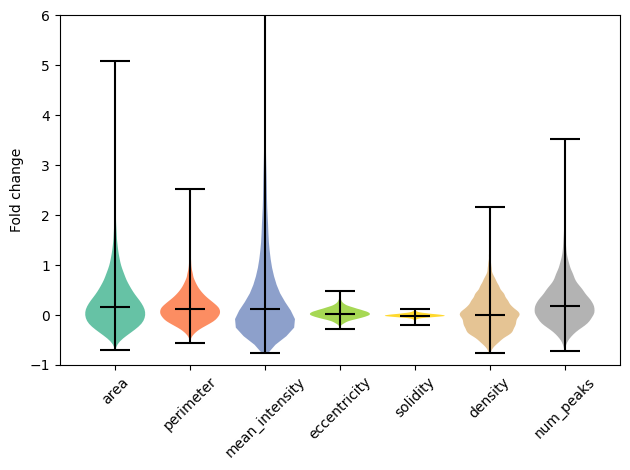

In [13]:
def fold_change_distribution(features: np.ndarray, labels: np.ndarray, feature_names: list[str]):
    os.makedirs(os.path.join(OUTPUT_DIR, "fold-change-distributions"), exist_ok=True)
    div12_features = features[labels == 0]
    div25_features = features[labels == 4]
    cmap = plt.get_cmap("Set2", len(feature_names))
    fig = plt.figure()
    ax = fig.add_subplot(111)
    pos = 0
    for feature_idx, feature_name in enumerate(feature_names):
        div12_feat, div25_feat = div12_features[:, feature_idx], div25_features[:, feature_idx] 

        violin_data = []
        for i in range(len(div25_feat)):
            datapoint = div25_feat[i]
            all_fold_changes = (datapoint - div12_feat) / div12_feat 
            violin_data.extend(all_fold_changes.tolist())

        
    
        violins = ax.violinplot(violin_data, positions=[pos], showmedians=True, widths=0.4)

        for body in violins["bodies"]:
            body.set_facecolor(cmap(feature_idx))
            body.set_alpha(1.0)

        for collection in (
            violins['cmins'], violins['cmaxes'], violins['cbars'], violins['cmedians'],
        ):
            collection.set_color("black")
        pos += 0.5

    ax.set_ylabel("Fold change")
    ax.set_xticks([0, 0.5, 1, 1.5, 2, 2.5, 3])
    ax.set_xticklabels(feature_names, rotation=45)
    ax.set_ylim(-1, 6)
    plt.tight_layout()
    plt.show()
    plt.close(fig)
    fig.savefig(os.path.join(OUTPUT_DIR, "fold-change-distribution.pdf"), dpi=900, transparent=True, bbox_inches="tight")
            

fold_change_distribution(
    features=train_real_features,
    labels=train_real_labels,
    feature_names=["area", "perimeter", "mean_intensity", "eccentricity", "solidity", "density",  "num_peaks"]
)


(85, 8) (135, 8)
(186, 8) (186, 8)
[---] area [---]
	fraction_real_12: 4.7059, fraction_real_25: 3.7037
	fraction_real_12_generated: 1.0753, fraction_real_25_generated: 11.8280
	fraction_real: 4.0909, fraction_generated: 6.4516
[---] perimeter [---]
	fraction_real_12: 3.5294, fraction_real_25: 5.1852
	fraction_real_12_generated: 0.5376, fraction_real_25_generated: 11.2903
	fraction_real: 4.5455, fraction_generated: 5.9140
[---] mean_intensity [---]
	fraction_real_12: 5.8824, fraction_real_25: 3.7037
	fraction_real_12_generated: 4.8387, fraction_real_25_generated: 6.4516
	fraction_real: 4.5455, fraction_generated: 5.6452
[---] eccentricity [---]
	fraction_real_12: 7.0588, fraction_real_25: 2.9630
	fraction_real_12_generated: 9.1398, fraction_real_25_generated: 5.9140
	fraction_real: 4.5455, fraction_generated: 7.5269
[---] solidity [---]
	fraction_real_12: 3.5294, fraction_real_25: 5.1852
	fraction_real_12_generated: 0.0000, fraction_real_25_generated: 12.3656
	fraction_real: 4.5455, fr

/tmp/ipykernel_116076/845992113.py:12: RuntimeWarning: divide by zero encountered in log10
  pval = -np.log10(pval)


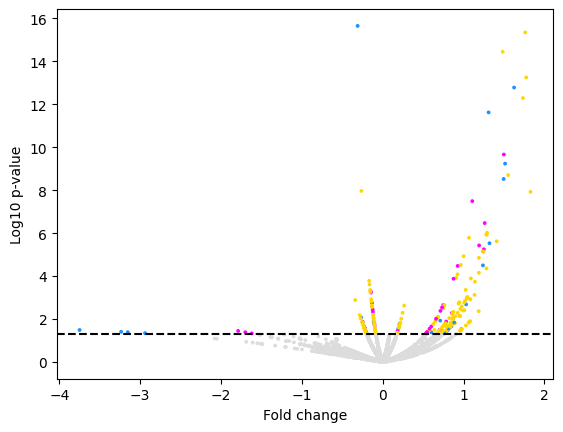

--------------------------------
full_real_fraction: 4.4805
full_generated_fraction: 5.7220


In [14]:
from scipy.stats import norm

def compute_pval(samples, x):
    # check if x exists in samples, if so, remove from samples
    samples = np.array(samples)
    if x in samples:
        samples = samples[samples != x]
    mu = np.mean(samples)
    std = np.std(samples)
    zscore = (x - mu) / std
    pval = 2 * (1 - norm.cdf(abs(zscore)))
    pval = -np.log10(pval)
    fc = np.log2(x / mu)
    return pval, fc

def feature_volcanos(real_features: np.ndarray, real_labels: np.ndarray, real_distances: np.ndarray, generated_features: np.ndarray, feature_names: list[str]):
    div12_features = real_features[real_labels == 0]
    div25_features = real_features[real_labels == 4]
    generated_young_0 = generated_features[:, [0], :]
    generated_distances_0 = [-1.05] * len(generated_young_0)
    generated_young_1 = generated_features[:, [1], :]
    generated_distances_1 = [-0.65] * len(generated_young_1)
    generated_young_2 = generated_features[:, [2], :]
    generated_distances_2 = [-0.24] * len(generated_young_2)
    generated_old_0 = generated_features[:, [3], :]
    generated_distances_3 = [0.17] * len(generated_old_0)
    generated_old_1 = generated_features[:, [4], :]
    generated_distances_4 = [0.57] * len(generated_old_1)
    generated_old_2 = generated_features[:, [5], :]
    generated_distances_5 = [0.98] * len(generated_old_2)
    generated_young = np.concatenate([generated_young_0, generated_young_1, generated_young_2], axis=0).squeeze()
    generated_young_labels = np.concatenate([generated_distances_0, generated_distances_1, generated_distances_2], axis=0)
    generated_old = np.concatenate([generated_old_0, generated_old_1, generated_old_2], axis=0).squeeze()
    generated_old_labels = np.concatenate([generated_distances_3, generated_distances_4, generated_distances_5], axis=0)
    print(div12_features.shape, div25_features.shape)
    print(generated_young.shape, generated_old.shape)

    full_real = 0
    full_real_total = 0
    full_generated = 0
    full_generated_total = 0
    fig = plt.figure()
    ax = fig.add_subplot(111)

    for feature_idx, feature_name in enumerate(feature_names):
        print(f"[---] {feature_name} [---]")
        div12_feat = div12_features[:, feature_idx]
        div12_distances = real_distances[real_labels == 0]
        div25_feat = div25_features[:, feature_idx]
        div25_distances = real_distances[real_labels == 4]
        generated_young_feat = generated_young[:, feature_idx]
        generated_old_feat = generated_old[:, feature_idx]
        div12_data = [compute_pval(div12_feat, x) for x in div12_feat]
        div12_pvals = [x[0] for x in div12_data]
        div12_fc = [x[1] for x in div12_data]
        div25_data = [compute_pval(div25_feat, x) for x in div25_feat]
        div25_pvals = [x[0] for x in div25_data]
        div25_fc = [x[1] for x in div25_data]
        generated_young_data = [compute_pval(div12_feat, x) for x in generated_young_feat]
        generated_young_pvals = [x[0] for x in generated_young_data]
        generated_young_fc = [x[1] for x in generated_young_data]
        generated_old_data = [compute_pval(div25_feat, x) for x in generated_old_feat]
        generated_old_pvals = [x[0] for x in generated_old_data]
        generated_old_fc = [x[1] for x in generated_old_data]


        yline = -np.log10(0.05)

        num25 = np.sum(div25_pvals > yline)  
        num12 = np.sum(div12_pvals > yline) 
        num25_total = len(div25_pvals) 
        num12_total = len(div12_pvals)
        num_real = num12 + num25
        num_real_total = num12_total + num25_total 
        # print(f"\tnum_real: {num_real}, num_real_total: {num_real_total}")
        # print(f"\tnum12: {num12}, num12_total: {num12_total}")
        # print(f"\tnum25: {num25}, num25_total: {num25_total}")
        fraction_real_12 = num12 / num12_total
        fraction_real_25 = num25 / num25_total
        print(f"\tfraction_real_12: {fraction_real_12*100:.4f}, fraction_real_25: {fraction_real_25*100:.4f}")
        
        num12_generated = np.sum(generated_young_pvals > yline) 
        num25_generated = np.sum(generated_old_pvals > yline)
        num_generated = num12_generated + num25_generated
        num12_generated_total = len(generated_young_pvals) 
        num25_generated_total = len(generated_old_pvals)
        num_generated_total = num12_generated_total + num25_generated_total
        # print(f"\tnum_generated: {num_generated}, num_generated_total: {num_generated_total}")
        # print(f"\tnum12_generated: {num12_generated}, num12_generated_total: {num12_generated_total}")
        # print(f"\tnum25_generated: {num25_generated}, num25_generated_total: {num25_generated_total}")

        fraction_real = num_real / num_real_total
        fraction_generated = num_generated / num_generated_total
        fraction_real_12_generated = num12_generated / num12_generated_total
        fraction_real_25_generated = num25_generated / num25_generated_total
        print(f"\tfraction_real_12_generated: {fraction_real_12_generated*100:.4f}, fraction_real_25_generated: {fraction_real_25_generated*100:.4f}")

        print(f"\tfraction_real: {fraction_real*100:.4f}, fraction_generated: {fraction_generated*100:.4f}")

        full_real += num_real
        full_real_total += num_real_total
        full_generated += num_generated
        full_generated_total += num_generated_total
        
        # fig = plt.figure()
        # ax = fig.add_subplot(111)
        # ax.scatter([item * -1 for item in div12_distances], div12_pvals, c="dodgerblue", s=7)
        # ax.scatter([item * -1 for item in div25_distances], div25_pvals, c="fuchsia", s=7)
        # ax.scatter(generated_young_labels, generated_young_pvals, c="green", s=7)
        # ax.scatter(generated_old_labels, generated_old_pvals, c="green", s=7)
        div12_colors = ["dodgerblue" if pval > yline else "gainsboro" for pval in div12_pvals]
        div25_colors = ["fuchsia" if pval > yline else "gainsboro" for pval in div25_pvals]
        young_colors = ["gold" if pval > yline else "gainsboro" for pval in generated_young_pvals]
        old_colors = ["gold" if pval > yline else "gainsboro" for pval in generated_old_pvals]
        ax.scatter(div12_fc, div12_pvals, c=div12_colors, s=3)
        ax.scatter(div25_fc, div25_pvals, c=div25_colors, s=3)
        ax.scatter(generated_young_fc, generated_young_pvals, c=young_colors, s=3)
        ax.scatter(generated_old_fc, generated_old_pvals, c=old_colors, s=3)
    ax.axhline(yline, color="black", linestyle="--")
    ax.set_xlabel("Fold change")
    ax.set_ylabel("Log10 p-value")
    # ax.set_title(f"{feature_name}\nreal: {fraction_real:.2f}\ngenerated: {fraction_generated:.2f}")
    plt.show()
    plt.close(fig)
    full_real_fraction = full_real / full_real_total
    full_generated_fraction = full_generated / full_generated_total
    print("--------------------------------")
    print(f"full_real_fraction: {full_real_fraction*100:.4f}\nfull_generated_fraction: {full_generated_fraction*100:.4f}")
            
        
feature_volcanos(
    real_features=valid_real_features,
    real_labels=valid_real_labels,
    real_distances=valid_real_distances,
    generated_features=all_trajectory_features,
    feature_names=["area", "perimeter", "mean_intensity", "eccentricity", "solidity", "density",  "num_peaks"]
)

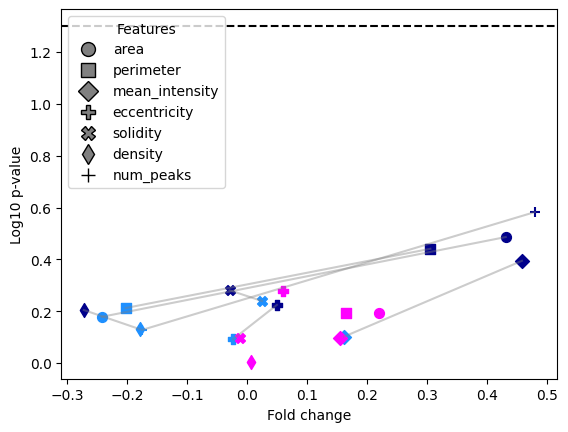

In [15]:
def compute_mean_pval(x, mu, std):
    # check if x exists in samples, if so, remove from samples
    zscore = (x - mu) / std
    pval = 2 * (1 - norm.cdf(abs(zscore)))
    pval = -np.log10(pval)
    fc = np.log2(x / mu)
    return pval, fc

def feature_mean_volcanos(real_features: np.ndarray, real_labels: np.ndarray, real_distances: np.ndarray, generated_features: np.ndarray, feature_names: list[str]):
    div12_features = real_features[real_labels == 0]
    div25_features = real_features[real_labels == 4]
    generated_young_0 = generated_features[:, [0], :]
    generated_distances_0 = [-1.05] * len(generated_young_0)
    generated_young_1 = generated_features[:, [1], :]
    generated_distances_1 = [-0.65] * len(generated_young_1)
    generated_young_2 = generated_features[:, [2], :]
    generated_distances_2 = [-0.24] * len(generated_young_2)
    generated_old_0 = generated_features[:, [3], :]
    generated_distances_3 = [0.17] * len(generated_old_0)
    generated_old_1 = generated_features[:, [4], :]
    generated_distances_4 = [0.57] * len(generated_old_1)
    generated_old_2 = generated_features[:, [5], :]
    generated_distances_5 = [0.98] * len(generated_old_2)
    generated_young = np.concatenate([generated_young_0, generated_young_1, generated_young_2], axis=0).squeeze()
    generated_young_labels = np.concatenate([generated_distances_0, generated_distances_1, generated_distances_2], axis=0)
    generated_old = np.concatenate([generated_old_0, generated_old_1, generated_old_2], axis=0).squeeze()
    generated_old_labels = np.concatenate([generated_distances_3, generated_distances_4, generated_distances_5], axis=0)

    fig = plt.figure()
    ax = fig.add_subplot(111)
    markers = {
        "area": "o",
        "perimeter": "s",
        "mean_intensity": "D",
        "eccentricity": "P",
        "solidity": "X",
        "density": "d",
        "num_peaks": "+"
    }

    for feature_idx, feature_name in enumerate(feature_names):
        div12_feat = div12_features[:, feature_idx]
        div12_distances = real_distances[real_labels == 0]
        div25_feat = div25_features[:, feature_idx]
        div25_distances = real_distances[real_labels == 4]
        generated_young_feat = generated_young[:, feature_idx]
        generated_old_feat = generated_old[:, feature_idx]
        div12_mean = np.mean(div12_feat) 
        div12_std = np.std(div12_feat)
        div25_mean = np.mean(div25_feat) 
        generated_young_mean = np.mean(generated_young_feat)
        generated_old_mean = np.mean(generated_old_feat) 
        
        young_pval, young_fc = compute_mean_pval(generated_young_mean, div12_mean, div12_std)
        div25_pval, div25_fc = compute_mean_pval(div25_mean, div12_mean, div12_std)
        old_pval, old_fc = compute_mean_pval(generated_old_mean, div12_mean, div12_std)
        ax.plot([young_fc, old_fc], [young_pval, old_pval], color="grey", alpha=0.4)
        ax.scatter(young_fc, young_pval, color="dodgerblue", marker=markers[feature_name], s=50)
        ax.scatter(div25_fc, div25_pval, color="fuchsia", marker=markers[feature_name], s=50)
        ax.scatter(old_fc, old_pval, color="darkblue", marker=markers[feature_name], s=50)
 
    from matplotlib.lines import Line2D

    # Create custom legend handles for each feature and marker
    legend_elements = [
        Line2D(
            [0], [0], 
            marker=marker, 
            color='w', 
            markerfacecolor='gray', 
            markeredgecolor='black',
            markersize=10, 
            label=feature_name
        )
        for feature_name, marker in markers.items()
    ]
    ax.legend(handles=legend_elements, title="Features", loc='upper left')
    yline = -np.log10(0.05)
    xline = 1.0 
    ax.axhline(yline, color="black", linestyle="--")
    ax.set_xlabel("Fold change")
    ax.set_ylabel("Log10 p-value")
    # ax.set_title(f"{feature_name}\nreal: {fraction_real:.2f}\ngenerated: {fraction_generated:.2f}")
    plt.show()
    plt.close(fig)


       

normalized_trajectory_features = (all_trajectory_features - valid_minimum) / (valid_maximum - valid_minimum)
        
feature_mean_volcanos(
    real_features=valid_real_features,
    real_labels=valid_real_labels,
    real_distances=valid_real_distances,
    generated_features=all_trajectory_features,
    feature_names=["area", "perimeter", "mean_intensity", "eccentricity", "solidity", "density",  "num_peaks"]
)

### Real images distance to boundary vs. features

(1212, 1) (1212,)
-3.4726972742782487 6.239841081970225


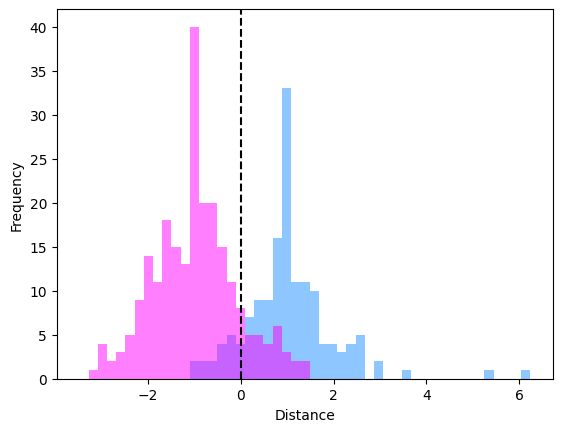

In [16]:
def plot_histogram(distances_to_boundary: np.ndarray, labels: np.ndarray):
    print(distances_to_boundary.shape, labels.shape)
    unique_labels = np.unique(labels)
    fig = plt.figure()
    ax = fig.add_subplot(111)

    m = np.min(distances_to_boundary)
    M = np.max(distances_to_boundary)
    print(m, M)

    distances_c1 = distances_to_boundary[labels == unique_labels[0]] 
    distances_c2 = distances_to_boundary[labels == unique_labels[-1]]
    ax.hist(distances_c1, bins=np.linspace(m, M, 50), alpha=0.5, color='dodgerblue', label="DIV25")
    ax.hist(distances_c2, bins=np.linspace(m, M, 50), alpha=0.5, color='fuchsia', label="DIV12")

    ax.axvline(0.0, color='black', linestyle='--', label="Decision boundary")
    ax.set_xlabel("Distance")   
    ax.set_ylabel("Frequency")
    plt.show()
    fig.savefig(os.path.join(OUTPUT_DIR, f"distance_histogram.pdf"), dpi=900, transparent=True)

plot_histogram(train_real_distances, train_real_labels)

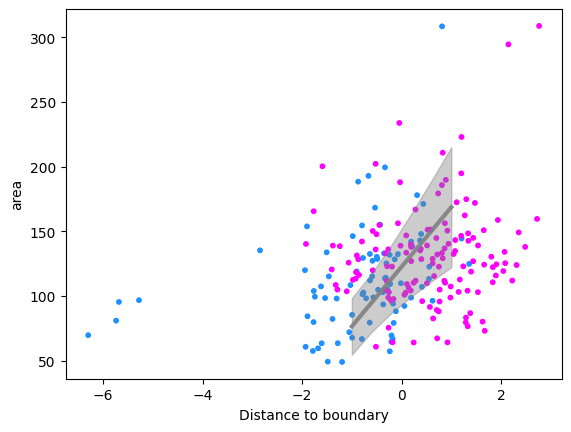

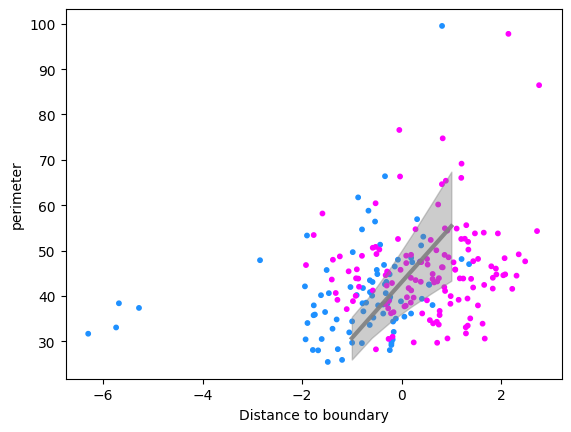

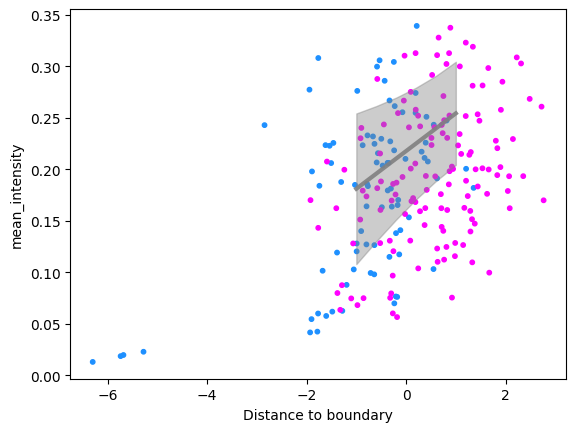

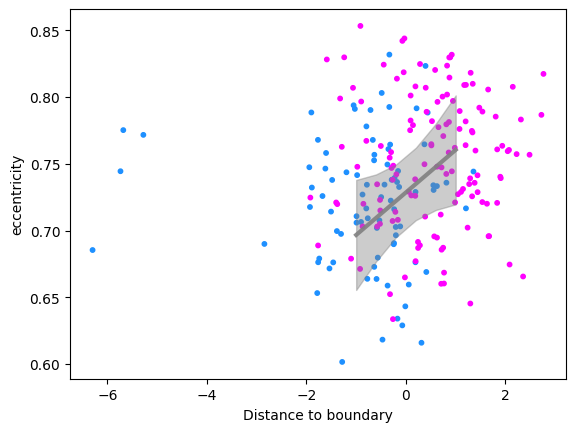

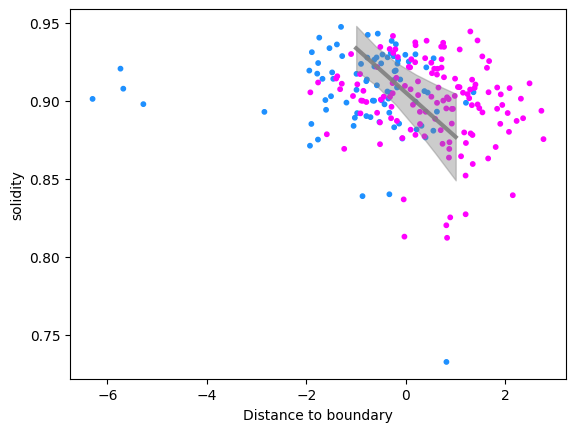

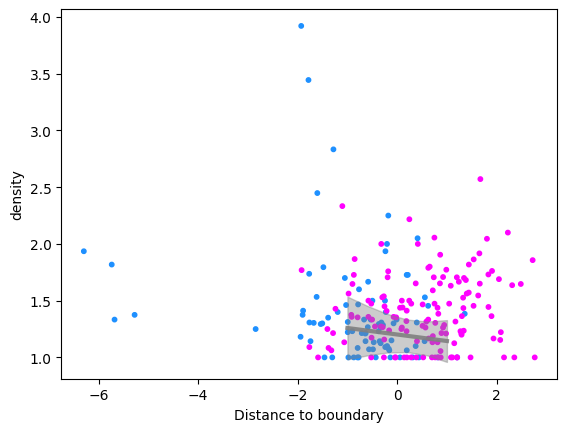

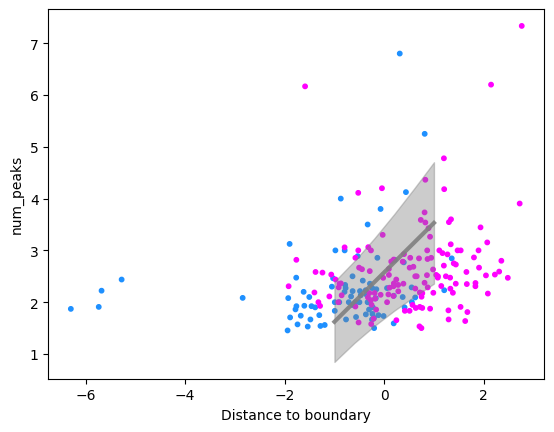

In [ ]:
def timesteps_vs_features(features: np.ndarray, fig, ax, feature_idx):
    feature_names = ["area", "perimeter", "mean_intensity", "eccentricity", "solidity", "density",  "num_peaks"]# , "num_proteins"]
    distances = [-1, -0.6, -0.2, 0.2, 0.6, 1.0]
    num_features = features.shape[-1]
    feature_data = features[:, :, feature_idx]
    all_ys = []
    for traj_idx in range(feature_data.shape[0]):
        x = np.array(distances)
        y = np.array(feature_data[traj_idx])
        m, c = compute_least_squares(x, y)
        all_ys.append(m * x + c)
        # ax.scatter(x, y, color="gray", s=10)
        
        # ax.plot(x, m * x + c, color="grey", alpha=0.5)
    all_ys = np.array(all_ys)
    mean_y = np.mean(all_ys, axis=0)
    std_y = np.std(all_ys, axis=0) 
    ax.plot(distances, mean_y, color="grey", linewidth=3, alpha=0.9)
    ax.fill_between(distances, mean_y - std_y, mean_y + std_y, color="grey", alpha=0.4)
    return fig, ax
       
def compute_least_squares(x, y):
    if isinstance(x, list):
        x = np.array(x)
    if isinstance(y, list):
        y = np.array(y)
    if x.ndim == 2:
        x = x[:, 0]
    A = np.vstack([x, np.ones(len(x))]).T
    m, c = np.linalg.lstsq(A, y)[0]
    return m, c

def plot_distance_vs_features(features, labels, distances, gen_features: np.ndarray):
    feature_names = ["area", "perimeter", "mean_intensity", "eccentricity", "solidity", "density",  "num_peaks"]
    unique_labels = np.unique(labels)
    indices_div12 = np.where(labels == unique_labels[0])[0]
    indices_div25 = np.where(labels == unique_labels[-1])[0]
    indices = np.concatenate([indices_div12, indices_div25]) 
    features = features[indices]
    labels = labels[indices]
    distances = distances[indices] * -1
    colors = ["dodgerblue" if l == unique_labels[0] else "fuchsia" for l in labels]
    for feature_idx in range(features.shape[-1] - 1):
        feature_data = features[:, feature_idx]
        # fig, axs = plt.subplots(1, 2, figsize=(10, 5))
        fig = plt.figure(figsize=(4,3))
        ax = fig.add_subplot(111)

        ax.scatter(distances, feature_data, c=colors, s=10)
        ax.set_xlabel("Distance to boundary")
        ax.set_ylabel(feature_names[feature_idx])
        timesteps_vs_features(gen_features, fig, ax, feature_idx)


        # dist_c1 = distances[labels == unique_labels[0]].flatten() 
        # dist_c2 = distances[labels == unique_labels[-1]].flatten()  
        # features_c1 = feature_data[labels == unique_labels[0]].flatten()
        # features_c2 = feature_data[labels == unique_labels[-1]].flatten()
        # c1_cmap = seaborn.light_palette("dodgerblue", as_cmap=True)
        # c2_cmap = seaborn.light_palette("fuchsia", as_cmap=True)
        # seaborn.kdeplot(x=dist_c1, y=features_c1, ax=axs[1], color="dodgerblue", levels=5)
        # seaborn.kdeplot(x=dist_c2, y=features_c2, ax=axs[1], color="fuchsia", levels=5)
        ax.set_xlabel("Distance to boundary")
        ax.set_ylabel(feature_names[feature_idx])
        plt.show()
        fig.savefig(os.path.join(OUTPUT_DIR, f"distance_vs_{feature_names[feature_idx]}.pdf"), dpi=1200, transparent=True)
        
plot_distance_vs_features(valid_real_features, valid_real_labels, valid_real_distances, gen_features=all_trajectory_features)

### Comparing feature values at DIV endpoints

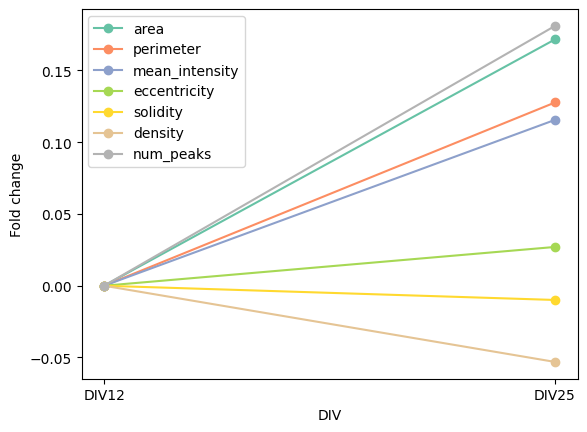

In [18]:
real_features = np.concatenate([train_real_features, valid_real_features], axis=0)
real_labels = np.concatenate([train_real_labels, valid_real_labels], axis=0)
# real_features = test_real_features 
# real_labels = test_real_labels 

def plot_endpoints(features, labels):
    feature_names = ["area", "perimeter", "mean_intensity", "eccentricity", "solidity", "density",  "num_peaks"]# , "num_proteins"]
    cmap = plt.get_cmap("Set2", len(feature_names))
    num_features = features.shape[1]
    
   
    ordered_data = []
    unique_labels = np.unique(labels)
    for label in [unique_labels[0], unique_labels[-1]]:
        indices = np.where(labels == label)[0]
        ordered_data.append(features[indices])
    
    fig = plt.figure()
    ax = fig.add_subplot(111)
    for feature_idx in range(num_features - 1):
        feature_data = [d[:, feature_idx] for d in ordered_data]

        mean_feature_data = np.array([np.mean(d) for d in feature_data])
        std_feature_data = np.array([np.std(d) for d in feature_data])
        foldchange_feature_data = (mean_feature_data - mean_feature_data[0]) / mean_feature_data[0]
       
        #std_feature_data = np.array([np.std(d) for d in feature_data])
        ax.plot(foldchange_feature_data, c=cmap(feature_idx), label=feature_names[feature_idx], marker="o")
        # ax.fill_between(np.arange(len(foldchange_feature_data)), foldchange_feature_data - foldchange_std_feature_data, foldchange_feature_data + foldchange_std_feature_data, color=cmap(feature_idx), alpha=0.2)
    ax.legend()
    ax.set_ylabel("Fold change")
    ax.set_xlabel("DIV")
    ax.set_xticks(np.arange(2))
    ax.set_xticklabels(["DIV12", "DIV25"])
    # ax.set_yscale("log")
    plt.show()
    fig.savefig(os.path.join(OUTPUT_DIR, f"endpoints.pdf"), dpi=900, transparent=True)

plot_endpoints(train_real_features, train_real_labels)

### Computing average feature values at every DIV

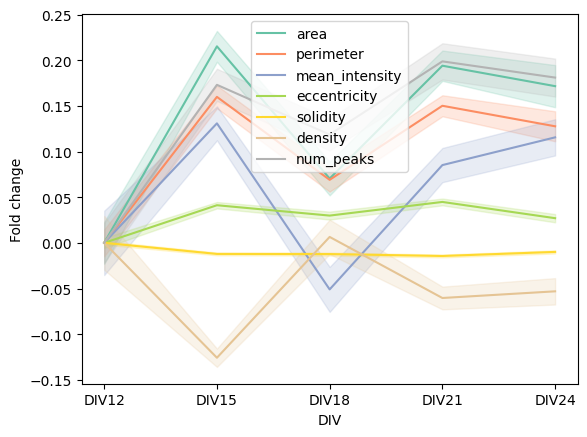

In [19]:


def plot_real_feature_averages(features, labels):
    feature_names = ["area", "perimeter", "mean_intensity", "eccentricity", "solidity", "density",  "num_peaks"]# , "num_proteins"]
    cmap = plt.get_cmap("Set2", len(feature_names))
    num_features = features.shape[1]
    
   
    ordered_data = []
    for label in np.unique(labels):
        indices = np.where(labels == label)[0]
        ordered_data.append(features[indices])
    
    fig = plt.figure()
    ax = fig.add_subplot(111)
    for feature_idx in range(num_features - 1):
        feature_data = [d[:, feature_idx] for d in ordered_data]
        
        baseline_mean = np.mean(feature_data[0])
        
        all_foldchanges = []
        for timepoint_data in feature_data:
            foldchanges_at_timepoint = (timepoint_data - baseline_mean) / baseline_mean
            all_foldchanges.append(foldchanges_at_timepoint)
        
        mean_foldchange = np.array([np.mean(fc) for fc in all_foldchanges])
        std_foldchange = np.array([np.std(fc) for fc in all_foldchanges])
        sem_foldchange = np.array([np.std(fc) / np.sqrt(len(fc)) for fc in all_foldchanges])
        
        ax.plot(mean_foldchange, c=cmap(feature_idx), label=feature_names[feature_idx])
        ax.fill_between(np.arange(len(mean_foldchange)), 
                        mean_foldchange - sem_foldchange, 
                        mean_foldchange + sem_foldchange, 
                        color=cmap(feature_idx), alpha=0.2)
    ax.legend()
    ax.set_ylabel("Fold change")
    ax.set_xlabel("DIV")
    ax.set_xticks(np.arange(len(mean_foldchange)))
    ax.set_xticklabels(["DIV12", "DIV15", "DIV18", "DIV21", "DIV24"])
    plt.show()
    fig.savefig(os.path.join(OUTPUT_DIR, f"real_feature_averages.pdf"), dpi=900, transparent=True)
    

plot_real_feature_averages(train_real_features, train_real_labels)

In [20]:
def bootstrap_real_trajectories(features, labels, n=1000):
    out = []
    for _ in trange(n):
        temp = []
        for label in [np.unique(labels)[0], np.unique(labels)[-1]]:
            indices = np.where(labels == label)[0]
            sample_features = features[indices]
            no_good = True 
            while no_good:
                bootstrap_sample = sample_features[np.random.randint(0, len(sample_features))]
                no_good = bootstrap_sample[5] == 0
            temp.append(bootstrap_sample)
        temp = np.array(temp)
        out.append(temp)
    out = np.array(out)
    return out



100%|██████████| 1000/1000 [00:00<00:00, 22039.56it/s]


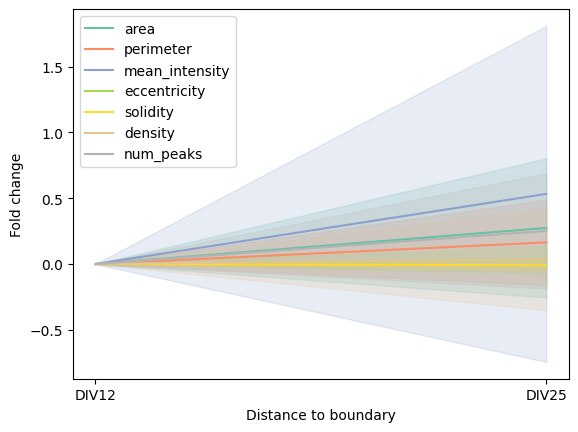

In [21]:
def plot_real_trajectories(features: np.ndarray, labels: np.ndarray, n: int = 1):
    bootstrap_trajectories = bootstrap_real_trajectories(features, labels, n=1000)
    feature_names = ["area", "perimeter", "mean_intensity", "eccentricity", "solidity", "density",  "num_peaks"]# , "num_proteins"]
    cmap = plt.get_cmap("Set2", len(feature_names))
    num_trajectories, num_timesteps, num_features = bootstrap_trajectories.shape 
    
    fig = plt.figure()
    ax = fig.add_subplot(111)
    for feature_idx in range(num_features - 1):
        feature_data = bootstrap_trajectories[:, :, feature_idx]
        feature_data = (feature_data - feature_data[:, 0:1]) / feature_data[:, 0:1]
        
        mean = np.mean(feature_data, axis=0)
        std_err = np.std(feature_data, axis=0)
        # sem_err = np.std(feature_data, axis=0) / np.sqrt(len(feature_data))
        cid, ciu = np.percentile(feature_data, 10.0, axis=0), np.percentile(feature_data, 90.0, axis=0)
        
        ax.plot(mean, c=cmap(feature_idx), label=feature_names[feature_idx])
        ax.fill_between(np.arange(num_timesteps), mean - std_err, mean + std_err, color=cmap(feature_idx), alpha=0.2)
        
        ax.set_xlabel("Distance to boundary")
        ax.set_ylabel("Fold change")
        ax.set_xticks(np.arange(2))
        ax.set_xticklabels(["DIV12", "DIV25"])
    ax.legend()
    plt.show()
    fig.savefig(os.path.join(OUTPUT_DIR, f"real_sampled_trajectories.pdf"), dpi=900, transparent=True)

plot_real_trajectories(train_real_features, train_real_labels, n=1)

# Synaptic Development Multidimensional Analysis

### Extracting deep features

In [22]:
def extract_deep_trajectories(encoder: nn.Module, files: np.ndarray, trajectory_ids: np.ndarray, timestep_ids: np.ndarray, device: torch.device):
    deep_features = []
    manual_features = []
    labels = [] 
    for f, timestep in zip(files, timestep_ids):
        img = tifffile.imread(f) 
        m_features = extract_features(img)
        if m_features.size == 0:
            continue 
        manual_features.append(np.mean(m_features, axis=0))

        img = torch.from_numpy(img).unsqueeze(0).unsqueeze(0).to(device)
        
        with torch.no_grad():
            features = encoder.forward_features(img)
        labels.append(timestep)
        deep_features.append(features)

    deep_features = torch.cat(deep_features, dim=0).cpu().numpy()
    manual_features = np.array(manual_features)
    labels = np.array(labels)
    return deep_features, manual_features, labels


deep_features, manual_features, deep_labels = extract_deep_trajectories(encoder=latent_encoder, files=files, trajectory_ids=trajectory_ids, timestep_ids=timestep_ids, device=DEVICE)
print(deep_features.shape, manual_features.shape, deep_labels.shape)

(372, 384) (372, 8) (372,)


### Clustering deep features

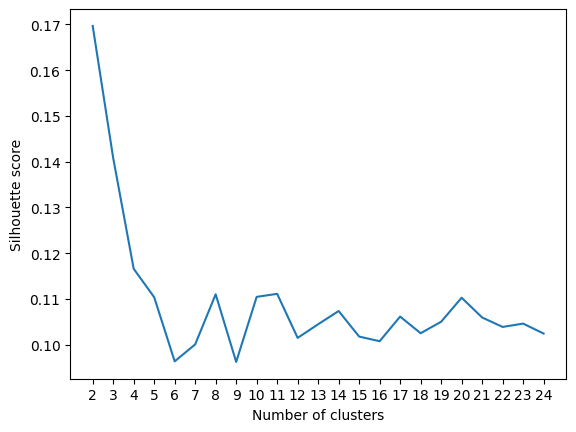

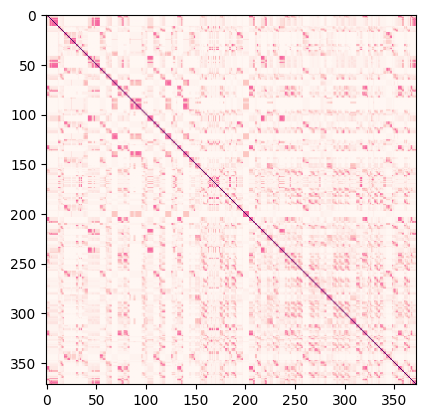

In [23]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score 


def cluster_deep_features(features: np.ndarray, n_clusters: int = 25):
    
    silhouettes = [] 
    Nd = len(features)
    cluster_matrix = np.zeros((Nd, Nd))
    for n in range(2, n_clusters):
        kmeans = KMeans(n_clusters=n, random_state=42).fit(features) 
        klabels = kmeans.labels_
        for j in range(Nd):
            for i in range(j, Nd):
                if klabels[j] == klabels[i]:
                    cluster_matrix[j, i] += 1
                    cluster_matrix[i, j] += 1
        score = silhouette_score(features, klabels) 
        silhouettes.append(score)
    fig = plt.figure()
    ax = fig.add_subplot(111)
    ax.plot(np.arange(2, n_clusters), silhouettes)
    ax.set_xticks(np.arange(2, n_clusters))
    ax.set_xticklabels(np.arange(2, n_clusters))
    ax.set_xlabel("Number of clusters")
    ax.set_ylabel("Silhouette score")
    plt.show()
    return cluster_matrix 

              
n_clusters = 25
cluster_matrix = cluster_deep_features(deep_features, n_clusters=n_clusters)
big_matrix = cluster_matrix / n_clusters

fig = plt.figure()
ax = fig.add_subplot(111)
ax.imshow(big_matrix, cmap="RdPu")
plt.show()

5.381895576839069
5


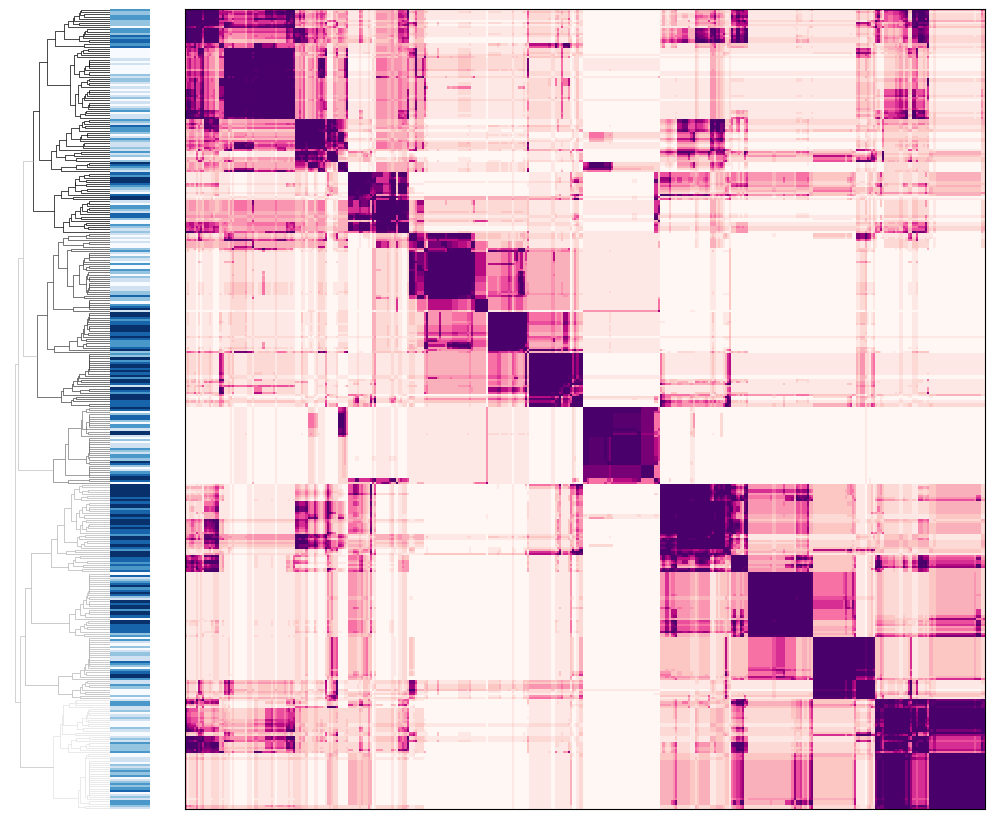

['1', '2', '3', '4', '5', '6'] [1 2 3 4 5]


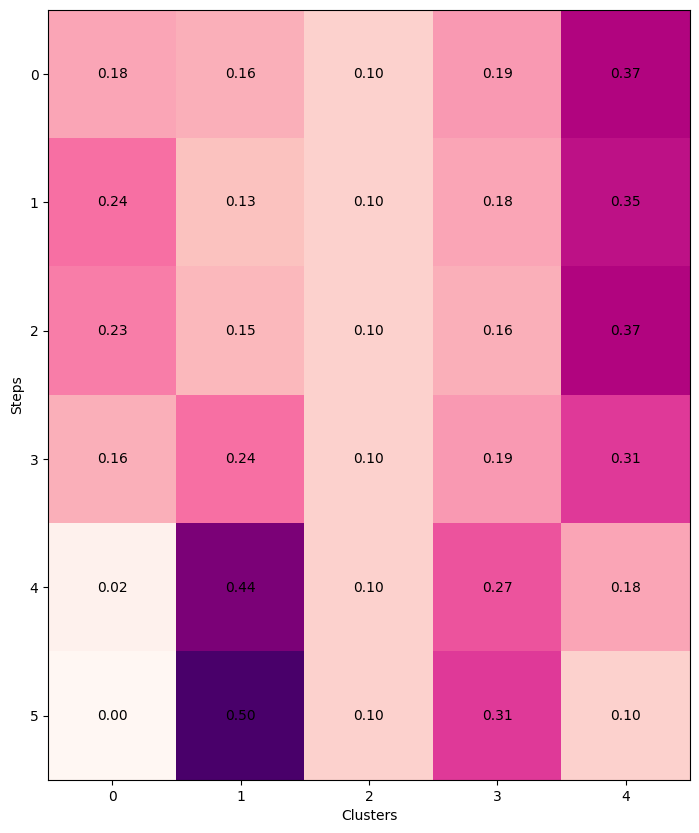

In [24]:
import matplotlib 
from scipy.spatial import distance 
from scipy.cluster import hierarchy 
from sklearn.preprocessing import StandardScaler 

SCALE = 0.8 

deep_trajectories = deep_features

scaler = StandardScaler()
deep_trajectories = scaler.fit_transform(deep_trajectories)
unique_names = np.unique(deep_labels).tolist()

timesteps = np.array([unique_names.index(name) for name in deep_labels])

D = big_matrix 
distances = distance.cdist(D, D)
mask = np.triu(np.ones_like(distances, dtype=bool)) * np.invert(np.eye(len(distances), dtype=bool))
dendrogram_distance = np.quantile(distances[mask], q=0.40)
print(dendrogram_distance)

Y = hierarchy.linkage(D, method="average", metric="euclidean")
Y2 = hierarchy.linkage(D.T, method="average", metric="euclidean")

h_labels = hierarchy.fcluster(Y, dendrogram_distance, "distance")
clusters_per_condition = h_labels
fig = plt.figure(figsize=(10, 10))
ax1 = fig.add_axes([0, 0, 0.1, SCALE])
ax1.set_xticks([])
ax1.set_yticks([])
fig.gca().invert_yaxis()
ax1.axis("off")

cmap = plt.get_cmap("Greys", (h_labels.max()).item() + 1)
print(h_labels.max())
hierarchy.set_link_color_palette([matplotlib.colors.to_hex(cmap(i+1)) for i in range(h_labels.max()+1)])
Z1 = hierarchy.dendrogram(
    Y,
    orientation="left",
    color_threshold=dendrogram_distance,
    above_threshold_color="silver",
    ax=ax1
)
Z2 = hierarchy.dendrogram(
    Y2,
    orientation="left",
    color_threshold=dendrogram_distance,
    above_threshold_color="silver",
    no_plot=True
)

for collection in ax1.collections:
    collection.set_linewidth(0.5)

ax2 = fig.add_axes([0.1, 0, 0.04, SCALE])
ax2.set_xticks([])
ax2.set_yticks([])
ax2.axis("off")

cmap = plt.get_cmap("Blues", len(set(timesteps)))
for i, leaf in enumerate(Z1["leaves"]):
    ax2.barh(i+0.5, 1, 1.0, color=cmap(timesteps[leaf]))

ax2.set(ylim=(0, len(Z1["leaves"])), xlim=(0, 1))

axmatrix = fig.add_axes([0.15, 0, 0.85, SCALE])
idx1 = Z1['leaves']
idx2 = Z2['leaves']

sorted_co_matrix = D[idx1, :]
sorted_co_matrix = sorted_co_matrix[:, idx2]
im = axmatrix.matshow(sorted_co_matrix, aspect="equal", origin="lower", cmap="RdPu", vmin=0, vmax=0.5)
axmatrix.set_xticks([])
axmatrix.set_yticks([])
fig.gca().invert_xaxis()

plt.show()
fig.savefig(os.path.join(OUTPUT_DIR, f"dendrogram.pdf"), dpi=900, transparent=True)
uniques = np.unique(h_labels)

print(unique_names, uniques) 
proportions = np.zeros((len(unique_names), len(uniques)))
for i, unique in enumerate(uniques):
    mask = h_labels == unique 
    timestep, counts = np.unique(timesteps[mask], return_counts=True)
    for t, c in zip(timestep, counts):
        proportions[t, i] = c 

proportions = proportions / np.sum(proportions, axis=1, keepdims=True)

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111)
ax.imshow(proportions, cmap="RdPu")
for j in range(proportions.shape[1]):
    for i in range(proportions.shape[0]):
        ax.text(j, i, f"{proportions[i, j]:.2f}", ha="center", va="center", color="black")
ax.set(
    xlabel="Clusters", ylabel="Steps"
)
plt.show()
fig.savefig(os.path.join(OUTPUT_DIR, f"proportions.pdf"), dpi=900, transparent=True)
        






(1, 7)
Cluster 1 has 51 proteins
Cluster 2 has 100 proteins
Cluster 3 has 36 proteins
Cluster 4 has 81 proteins
Cluster 5 has 104 proteins


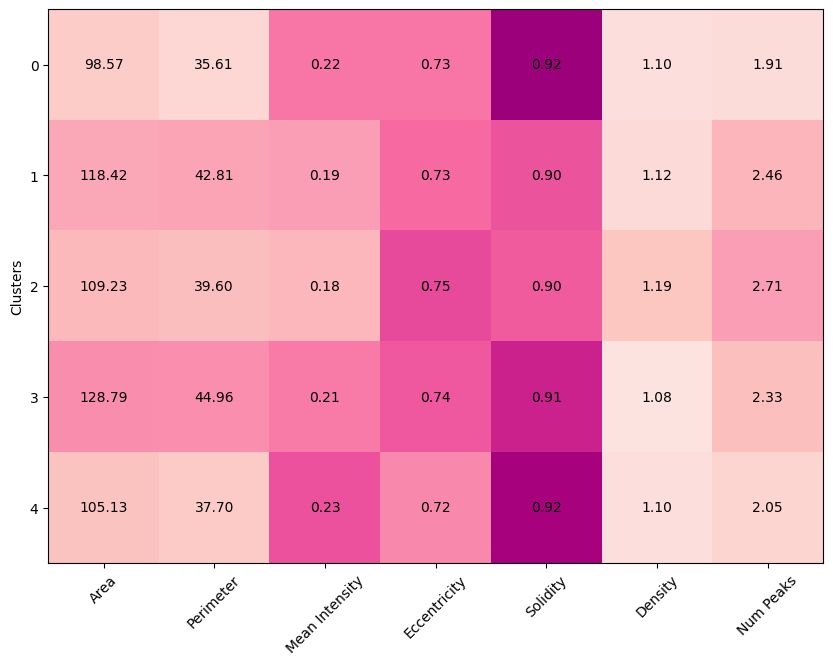

In [25]:
FEATURES = ["Area", "Perimeter", "Mean Intensity", "Eccentricity", "Solidity", "Density", "Num Peaks"]

class MaskedMinMaxScaler:
    def __init__(self):

        self.mean = None 
        self.std = None

        self.min = None
        self.max = None

    def fit_transform(self, X, mask):
        self.fit(X, mask)
        return self.transform(X)
    
    def fit(self, X, mask):
        # self.mean = numpy.mean(X, axis=0, keepdims=True)
        # self.std = numpy.std(X, axis=0, keepdims=True)
        #self.min = np.min(X, axis=0, keepdims=True)
        self.min = np.quantile(X, q=0.05, axis=0, keepdims=True)
        # self.max = np.max(X, axis=0, keepdims=True)
        self.max = np.quantile(X, q=0.95, axis=0, keepdims=True)
        # nn_max = np.quantile(X[:, 6], q=0.95)
        # self.max[0, 6] = nn_max

        mask = np.array(mask)
        # self.mean[:, ~mask] = 0
        # self.std[:, ~mask] = 1

        self.min[:, ~mask] = 0
        self.max[:, ~mask] = 1


    def transform(self, X):
        if self.min is None or self.max is None:
            raise ValueError("Scaler has not been fitted yet")
        
        print(self.min.shape)
        X_transformed = (X - self.min) / (self.max - self.min)
        return X_transformed, X 
    
trajectories = manual_features[:, :-1]

# scaler = StandardScaler()
# trajectories = scaler.fit_transform(deep_trajectories) 


scaler = MaskedMinMaxScaler()

# trajectories = scaler.fit_transform(trajectories, [f not in ["Eccentricity", "Solidity"] for f in final_features])
trajectories, original = scaler.fit_transform(trajectories, [True for _ in FEATURES])


deep_trajectories = deep_features 

unique_labels = np.unique(h_labels)
correlation_matrix = np.zeros((len(unique_labels), trajectories.shape[-1]))
original_matrix = np.zeros((len(unique_labels), original.shape[-1]))

for i, cluster_id in enumerate(unique_labels):
    mask = h_labels == cluster_id
    print(f"Cluster {cluster_id} has {np.sum(mask)} proteins")
    # d_traj = deep_trajectories[mask]
    t_traj = trajectories[mask]
    og_traj = original[mask]
    for feature_idx in range(t_traj.shape[-1]):
        correlation_matrix[i, feature_idx] = np.median(t_traj[:, feature_idx])
        original_matrix[i, feature_idx] = np.median(og_traj[:, feature_idx])

# final_matrix = np.delete(correlation_matrix, 2, axis=1)
# final_features = np.delete(FEATURES, 2)


fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111)
ax.imshow(correlation_matrix, cmap="RdPu", vmin=0, vmax=1)
for i in range(correlation_matrix.shape[0]):
    for j in range(correlation_matrix.shape[1]):
        ax.text(j, i, f"{original_matrix[i, j]:.2f}", 
                ha="center", va="center", color="black")

ax.set(ylabel="Clusters")
ax.set_xticks(np.arange(0, correlation_matrix.shape[-1], 1), labels=[FEATURES[i] for i in range(correlation_matrix.shape[-1])], rotation=45)
plt.show()
fig.savefig(os.path.join(OUTPUT_DIR, f"multidim_matrix.pdf"), dpi=900, transparent=True)

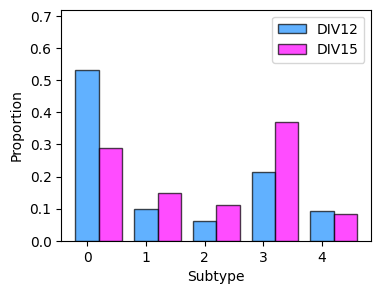

In [28]:
from scipy.spatial.distance import cdist

def check_real_subtypes(features: np.ndarray, labels: np.ndarray, subtypes: np.ndarray):
    proportions = {key: [] for key in range(len(subtypes))}
    div12_features = features[labels == 0]
    # div15_features = features[labels == 1]
    # div18_features = features[labels == 2]
    # div21_features = features[labels == 3]
    div25_features = features[labels == 4]

    div12_distances = cdist(div12_features, subtypes)
    div12_subtypes = np.argmin(div12_distances, axis=1)

    # div15_distances = cdist(div15_features, subtypes)
    # div15_subtypes = np.argmin(div15_distances, axis=1)

    # div18_distances = cdist(div18_features, subtypes)
    # div18_subtypes = np.argmin(div18_distances, axis=1)

    # div21_distances = cdist(div21_features, subtypes)
    # div21_subtypes = np.argmin(div21_distances, axis=1)
    
    div25_distances = cdist(div25_features, subtypes)   
    div25_subtypes = np.argmin(div25_distances, axis=1)
    
    div12_subtype_ids, div12_subtype_counts = np.unique(div12_subtypes, return_counts=True)
    div12_subtype_counts = div12_subtype_counts / len(div12_features)

    # div15_subtype_ids, div15_subtype_counts = np.unique(div15_subtypes, return_counts=True)
    # div15_subtype_counts = div15_subtype_counts / len(div15_features)

    # div18_subtype_ids, div18_subtype_counts = np.unique(div18_subtypes, return_counts=True)
    # div18_subtype_counts = div18_subtype_counts / len(div18_features)

    # div21_subtype_ids, div21_subtype_counts = np.unique(div21_subtypes, return_counts=True)
    # div21_subtype_counts = div21_subtype_counts / len(div21_features)

    div25_subtype_ids, div25_subtype_counts = np.unique(div25_subtypes, return_counts=True)
    div25_subtype_counts = div25_subtype_counts / len(div25_features)
    x1 = np.arange(len(subtypes))
    x2 = [item + 0.4 for item in x1]
    # x3 = [item + 0.15 for item in x2]
    # x4 = [item + 0.15 for item in x3]
    # x5 = [item + 0.15 for item in x4]
    fig = plt.figure(figsize=(4,3))
    ax = fig.add_subplot(111)
    ax.bar(x1, div12_subtype_counts, label="DIV12", width=0.4, color="dodgerblue", edgecolor="black", alpha=0.7)
    ax.bar(x2, div25_subtype_counts, label="DIV15", width=0.4, color="fuchsia", edgecolor="black", alpha=0.7)
    # ax.bar(x3, div18_subtype_counts, label="DIV18", width=0.15, color="grey")
    # ax.bar(x4, div21_subtype_counts, label="DIV21", width=0.15, color="black")
    # ax.bar(x5, div25_subtype_counts, label="DIV25", width=0.15, color="fuchsia")
    ax.set_xlabel("Subtype")
    ax.set_ylabel("Proportion")
    ax.set_ylim(0, 0.72)
    ax.legend()
    plt.show()
    fig.savefig(os.path.join(OUTPUT_DIR, f"real_div_proportions.pdf"), dpi=900, transparent=True)
    return div12_subtype_counts, div25_subtype_counts
   

real_young_counts, real_old_counts = check_real_subtypes(
    features=train_real_features[:, :-1],
    labels=train_real_labels,
    subtypes=original_matrix
)



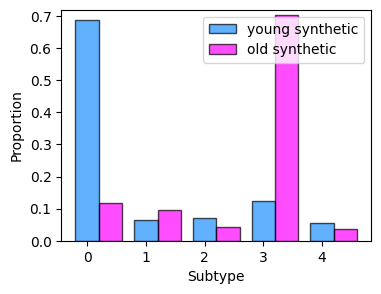

In [29]:
def check_fake_subtypes(gen_features: np.ndarray, subtypes: np.ndarray):
    young_features = gen_features[:, [0, 1, 2], :]
    old_features = gen_features[:, [3, 4, 5], :]
    
    young_features = np.concatenate(young_features, axis=0)
    old_features = np.concatenate(old_features, axis=0)

    young_distances = cdist(young_features, subtypes)
    young_subtypes = np.argmin(young_distances, axis=1)
    
    old_distances = cdist(old_features, subtypes)   
    old_subtypes = np.argmin(old_distances, axis=1)
    
    young_subtype_ids, young_subtype_counts = np.unique(young_subtypes, return_counts=True)
    young_subtype_counts = young_subtype_counts / len(young_features)
    old_subtype_ids, old_subtype_counts = np.unique(old_subtypes, return_counts=True)
    old_subtype_counts = old_subtype_counts / len(old_features)
    x1 = np.arange(len(subtypes))
    x2 = [item + 0.4 for item in x1]
    fig = plt.figure(figsize=(4, 3))
    ax = fig.add_subplot(111)
    ax.bar(x1, young_subtype_counts, label="young synthetic", width=0.4, color="dodgerblue", edgecolor="black", alpha=0.7)
    ax.bar(x2, old_subtype_counts, label="old synthetic", width=0.4, color="fuchsia", edgecolor="black", alpha=0.7)
    ax.set_xlabel("Subtype")
    ax.set_ylabel("Proportion")
    ax.set_ylim(0, 0.72)
    ax.legend()
    plt.show()
    fig.savefig(os.path.join(OUTPUT_DIR, f"generated_proportions.pdf"), dpi=900, transparent=True)
    return young_subtype_counts, old_subtype_counts
   


gen_young_counts, gen_old_counts = check_fake_subtypes(
    gen_features=all_trajectory_features[:, :, :-1],
    subtypes=original_matrix
)

  

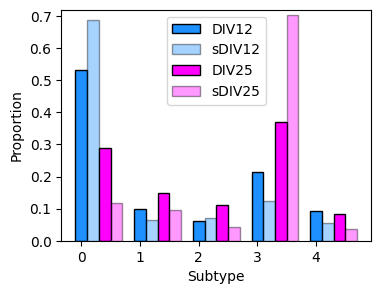

In [35]:
fig = plt.figure(figsize=(4,3))
ax = fig.add_subplot(111)
x1 = np.arange(len(real_young_counts)) 
x2 = [item + 0.2 for item in x1]
x3 = [item + 0.2 for item in x2]
x4 = [item + 0.2 for item in x3]
ax.bar(x1, real_young_counts, width=0.2, color="dodgerblue", edgecolor="black", alpha=1.0, label="DIV12")
ax.bar(x2, gen_young_counts, width=0.2, color="dodgerblue", edgecolor="black", alpha=0.4, label="sDIV12")
ax.bar(x3, real_old_counts, width=0.2, color="fuchsia", edgecolor="black", alpha=1.0, label="DIV25")
ax.bar(x4, gen_old_counts, width=0.2, color="fuchsia", edgecolor="black", alpha=0.4, label="sDIV25")
ax.set_xlabel("Subtype")
ax.set_ylabel("Proportion")
ax.set_ylim(0, 0.72)
ax.legend()
plt.show()
fig.savefig(os.path.join(OUTPUT_DIR, f"real_vs_generated_proportions.pdf"), dpi=900, transparent=True)
